In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("IPL_ball_by_ball_updated.csv")
df["start_date"] = pd.to_datetime(df["start_date"], errors="coerce")
df["total_runs"] = df["runs_off_bat"] + df["extras"]

print("Dataset loaded successfully")
print("Rows:", len(df))
print("Columns:", len(df.columns))

Dataset loaded successfully
Rows: 243815
Columns: 23


In [2]:
monthly = df.assign(month=df["start_date"].dt.to_period("M")).groupby("month")["total_runs"].sum().tail(24)
monthly.index = monthly.index.astype(str)
monthly

month
2015-04     9128
2015-05     9225
2016-04     8564
2016-05    10298
2017-04    11666
2017-05     7120
2018-04    10007
2018-05     9894
2019-03     4146
2019-04    11917
2019-05     3371
2020-09     4117
2020-10    12784
2020-11     2515
2021-04     8359
2021-05     1155
2021-09     4320
2021-10     4803
2022-03     2392
2022-04    12229
2022-05     9774
2023-03      360
2023-04    14499
2023-05    10829
Name: total_runs, dtype: int64

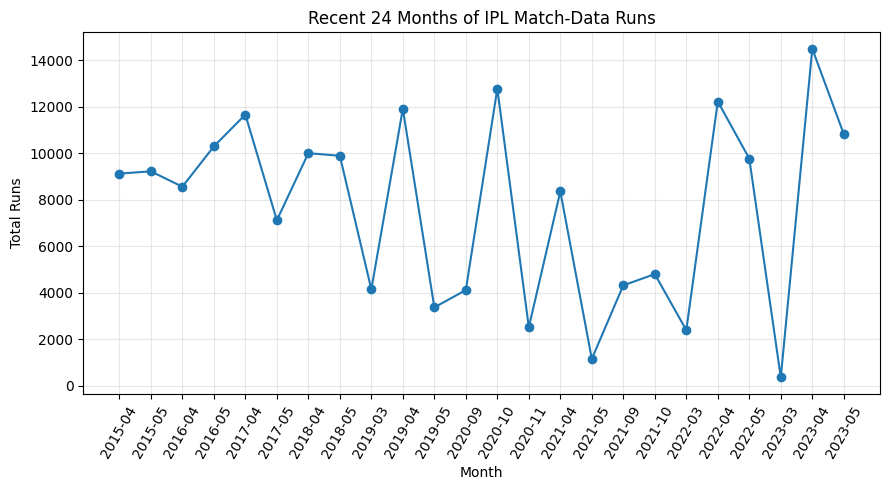

In [3]:
plt.figure(figsize=(9,5))
plt.plot(monthly.index, monthly.values, marker="o")
plt.title("Recent 24 Months of IPL Match-Data Runs")
plt.xlabel("Month")
plt.ylabel("Total Runs")
plt.xticks(rotation=60)
plt.grid(True, alpha=.3)
plt.tight_layout()
plt.show()

In [4]:
innings_runs = df.groupby("innings")["total_runs"].sum()
innings_runs

innings
1    167812
2    153686
3       137
4       123
5        11
6        15
Name: total_runs, dtype: int64

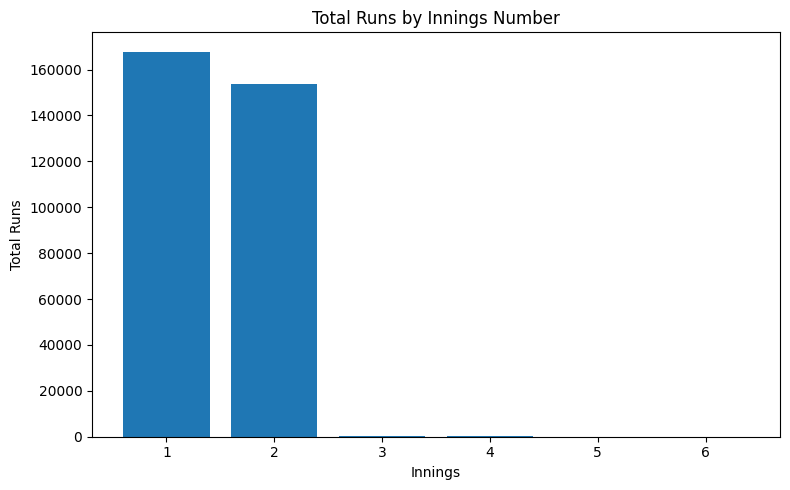

In [5]:
plt.figure(figsize=(8,5))
plt.bar(innings_runs.index.astype(str), innings_runs.values)
plt.title("Total Runs by Innings Number")
plt.xlabel("Innings")
plt.ylabel("Total Runs")
plt.tight_layout()
plt.show()

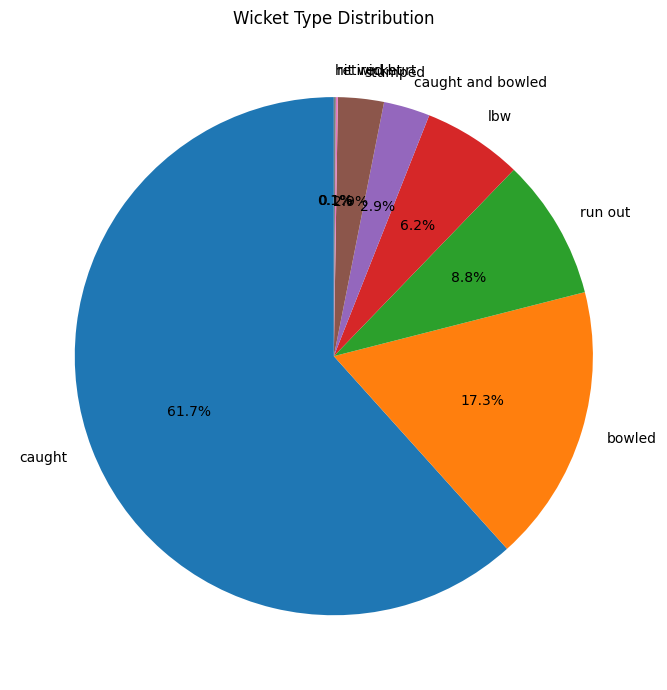

In [6]:
w = df.loc[df["wicket_type"].notna(),"wicket_type"].value_counts().head(8)
plt.figure(figsize=(7,7))
plt.pie(w.values, labels=w.index, autopct="%1.1f%%", startangle=90)
plt.title("Wicket Type Distribution")
plt.tight_layout()
plt.show()

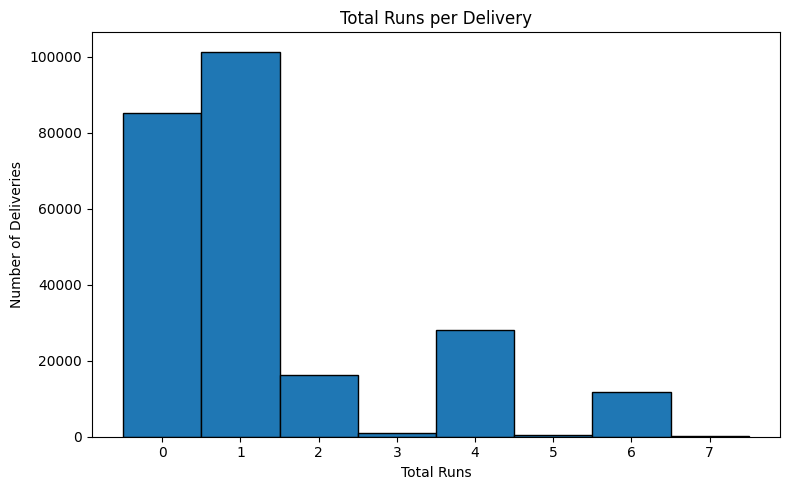

In [7]:
plt.figure(figsize=(8,5))
plt.hist(df["total_runs"], bins=range(0,9), edgecolor="black", align="left")
plt.title("Total Runs per Delivery")
plt.xlabel("Total Runs")
plt.ylabel("Number of Deliveries")
plt.xticks(range(0,8))
plt.tight_layout()
plt.show()

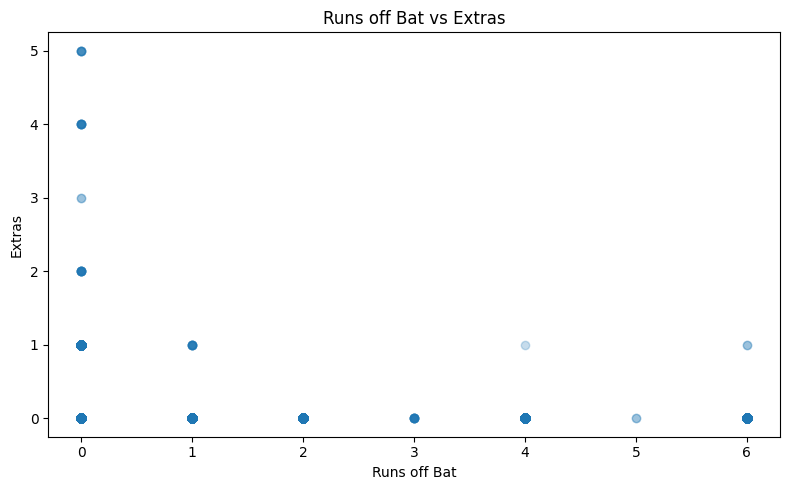

In [8]:
sample = df.sample(5000, random_state=42)
plt.figure(figsize=(8,5))
plt.scatter(sample["runs_off_bat"], sample["extras"], alpha=.25)
plt.title("Runs off Bat vs Extras")
plt.xlabel("Runs off Bat")
plt.ylabel("Extras")
plt.tight_layout()
plt.show()